In [71]:
import torch
from pathlib import Path
import preprocess_data as ppd
from process_session import session as ps
import process_probe as pp
import numpy as np
from preprocess_data import *
import models as models
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score
import pandas as pd
import sys
import multiprocessing 
import os
from captum.attr import IntegratedGradients

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
df = pd.read_csv('units_info.csv')
print(df.head())

      unit_id  session_id                                       genotype  \
0  1179685687  1047969464  Sst-IRES-Cre/wt;Ai32(RCL-ChR2(H134R)_EYFP)/wt   
1  1179685618  1047969464  Sst-IRES-Cre/wt;Ai32(RCL-ChR2(H134R)_EYFP)/wt   
2  1179685304  1047969464  Sst-IRES-Cre/wt;Ai32(RCL-ChR2(H134R)_EYFP)/wt   
3  1179685455  1047969464  Sst-IRES-Cre/wt;Ai32(RCL-ChR2(H134R)_EYFP)/wt   
4  1179684888  1047969464  Sst-IRES-Cre/wt;Ai32(RCL-ChR2(H134R)_EYFP)/wt   

   optotagged  cluster_id  pyr  sst  vip  
0           0           0    1    0    0  
1           0           0    1    0    0  
2           0           0    1    0    0  
3           0           4    0    0    0  
4           0           0    0    0    0  


In [4]:
# Session obj contains stimulus, channel, and unit information
output_dir  = r'Y:\buzsakilab\Buzsakilabspace\LabShare\NoamNitzan\Open_Access\Allen_2022'
session_id  = 1044385384
session_obj = ps(session_id, df, output_dir)

In [5]:
# hyperparameters
input_size = len(session_obj.units)
hidden_size = 50 # 
num_layers = 1
seqlength = 750
num_epochs = 15 # 
bands = [(0.5, 4), (4, 8), (8, 12), (12, 25), (25, 50), (50, 100), (100, 200), (200, 400)]
criterion  = torch.nn.MSELoss()
batch_size = 32

In [6]:
# Spikes obj contains Spike matrix
bin_size=0.004
spikes_obj = ppd.pre_process_spikes(session_obj.units, session_obj.spike_times, bin_size=bin_size, sigma=3)
spikes_obj.getSpkMat(session_obj.active_times[0], session_obj.active_times[1])
spikes_obj.truncate(seqlength)
spikes_obj.convolve_with_gaussian()
spikes_obj.zscore()

100%|██████████| 623/623 [01:01<00:00, 10.15it/s]


In [11]:
# Probe obj contains LFP data
# Getting LFP  for active trials
lfp_obj = ppd.pre_process_lfp(session_id, session_obj.channels, session_obj.active_times[0],
                              session_obj.active_times[1], output_dir) 
lfp_obj.filter_lfp()
lfp_obj.downsample_lfp(5) # Downsample by 5
lfp_obj.truncate(seqlength) # Downsample by 5
lfp_obj.align_lfp(spikes_obj.spkMat.shape[0])

100%|██████████| 8/8 [03:39<00:00, 27.47s/it]


In [15]:
# get spontaneous data
spikes_obj_spont = ppd.pre_process_spikes(session_obj.units, session_obj.spike_times, bin_size=bin_size, sigma=3)
spikes_obj_spont.getSpkMat(session_obj.spontaneous_times[0], session_obj.spontaneous_times[1])
spikes_obj_spont.truncate(seqlength)
spikes_obj_spont.convolve_with_gaussian()
spikes_obj_spont.zscore()

lfp_obj_spont = ppd.pre_process_lfp(session_id, session_obj.channels, session_obj.spontaneous_times[0],
                              session_obj.spontaneous_times[1], output_dir) 
lfp_obj_spont.filter_lfp()
lfp_obj_spont.downsample_lfp(5) # Downsample by 5
lfp_obj_spont.truncate(seqlength) # Downsample by 5
lfp_obj_spont.align_lfp(spikes_obj_spont.spkMat.shape[0])

100%|██████████| 8/8 [00:10<00:00,  1.28s/it]


In [12]:
chani = 5 # deep layer
bandi = 0 # broadband

X_train, X_test, y_train, y_test = chunk_and_reshape(spikes_obj.spkMat, lfp_obj.lfpMat[:,chani,bandi] , seqlength, test_size=0.2, random_state=42)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

train_dataloader, test_dataloader = get_data_loaders(X_train, X_test, y_train, y_test, batch_size , device)

test_spikes = torch.cat([X for X, _ in test_dataloader], dim=0)
test_lfp = torch.cat([y for _, y in test_dataloader], dim=0)

# reshape to time X features
test_spikes = test_spikes.reshape(test_spikes.shape[0] * test_spikes.shape[1], test_spikes.shape[2])
test_lfp = test_lfp.reshape(test_lfp.shape[0] * test_lfp.shape[1])

(960, 750, 623) (241, 750, 623) (960, 750, 1) (241, 750, 1)


## compare models

In [13]:
# linear regression model 
linear_model = models.LinearRegressionModel(input_size)
ln_train_loss, ln_test_loss = linear_model.train(train_dataloader,
                                               test_dataloader, numepochs=1)

print(f'Linear regression train loss: {ln_train_loss[-1]:.4f}')
print(f'Linear regression test loss: {ln_test_loss[-1]:.4f}')

Linear regression train loss: 0.3726
Linear regression test loss: 0.5475


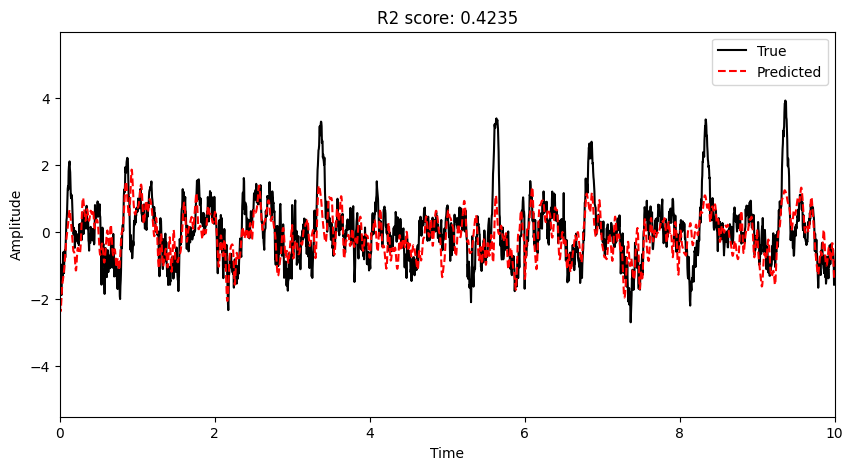

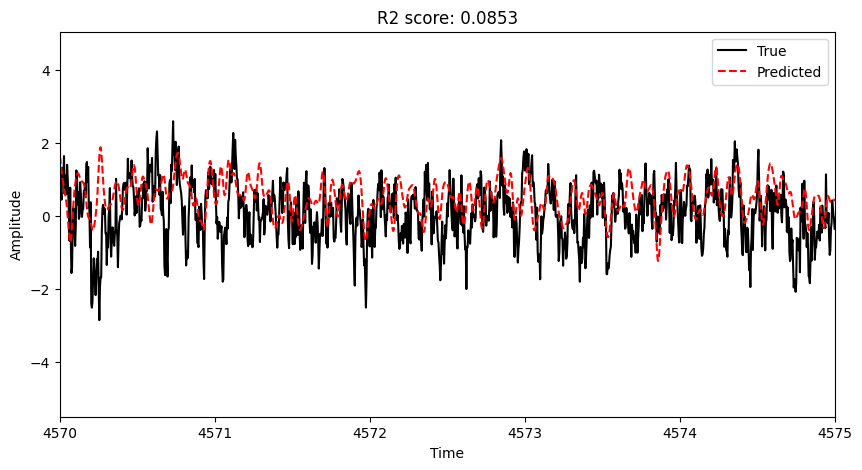

In [16]:
# 3. Evaluate the linear model
y_hat_test = linear_model.evaluate(test_spikes)

time_test = np.linspace(0, test_lfp.shape[0] * bin_size , test_lfp.shape[0])

fig, ax = plt.subplots(1, 1, figsize=(10, 5))
ax.plot(time_test, test_lfp.cpu().numpy(), 'k', label='True')
ax.plot(time_test, y_hat_test, '--r', label='Predicted')
ax.set_xlim([0, 10])
ax.set_xlabel('Time')
ax.set_ylabel('Amplitude')
ax.set_title(f'R2 score: {r2_score(test_lfp.cpu().numpy(), y_hat_test):.4f}')
ax.legend()
plt.show()

y_hat_spont = linear_model.evaluate(torch.tensor(spikes_obj_spont.spkMat).float())

fig, ax = plt.subplots(1, 1, figsize=(10, 5))
ax.plot(spikes_obj_spont.timestamps, lfp_obj_spont.lfpMat[:,chani,bandi], 'k', label='True')
ax.plot(spikes_obj_spont.timestamps, y_hat_spont, '--r', label='Predicted')
ax.set_xlim([spikes_obj_spont.timestamps[0], spikes_obj_spont.timestamps[0]+5])
ax.set_xlabel('Time')
ax.set_ylabel('Amplitude')
ax.set_title(f'R2 score: {r2_score(lfp_obj_spont.lfpMat[:,chani,bandi], y_hat_spont):.4f}')
ax.legend()
plt.show()


In [17]:
# LSTM model

lstm_model = models.process_model(models.LSTMnet(input_size, hidden_size, num_layers,seqlength), criterion, device)
lstm_train_loss, lstm_test_loss = lstm_model.train(train_dataloader,
                                        test_dataloader , num_epochs)

print(f'LSTM  train loss: {lstm_train_loss[-1]:.4f}')
print(f'LSTM  test loss: {lstm_test_loss[-1]:.4f}')

LSTM  train loss: 0.1554
LSTM  test loss: 0.3078


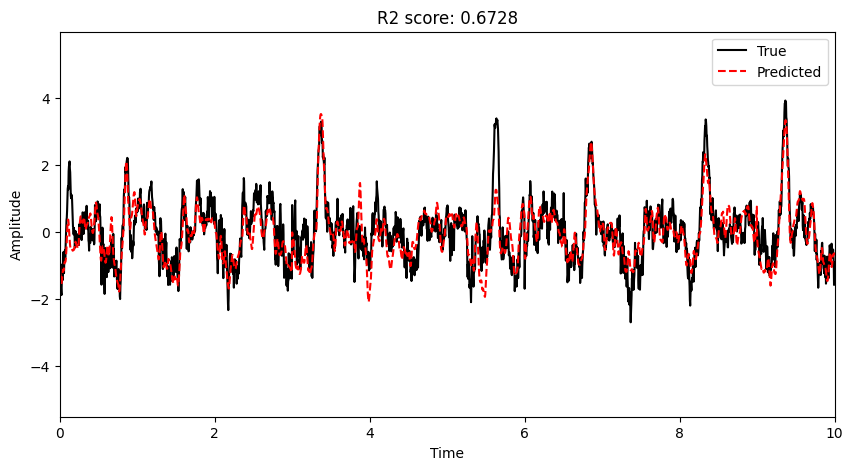

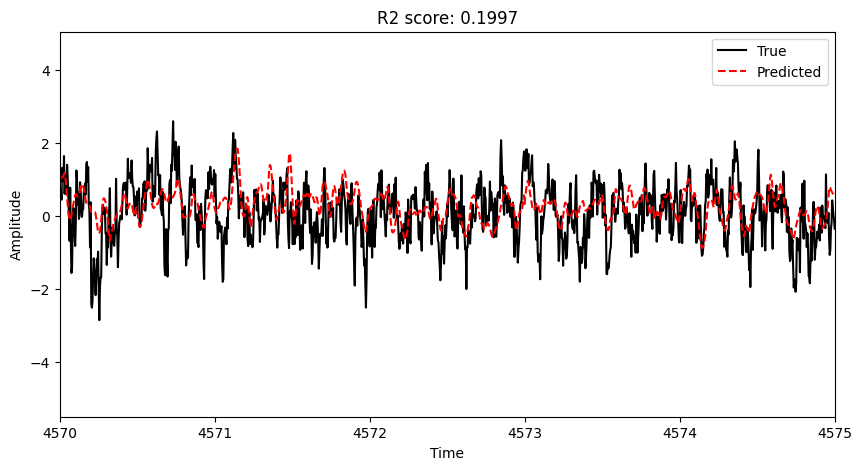

In [18]:
y_hat_test = lstm_model.evaluate(test_dataloader.dataset.tensors[0])

time = np.linspace(0, test_lfp.shape[0] * bin_size , test_lfp.shape[0])

fig, ax = plt.subplots(1, 1, figsize=(10, 5))
ax.plot(time, test_lfp.cpu().numpy(), 'k', label='True')
ax.plot(time, y_hat_test, '--r', label='Predicted')
ax.set_xlim([0, 10])
ax.set_xlabel('Time')
ax.set_ylabel('Amplitude')
ax.set_title(f'R2 score: {r2_score(test_lfp.cpu().numpy(), y_hat_test):.4f}')
ax.legend()
plt.show()

y_hat_spont = lstm_model.evaluate(torch.tensor(spikes_obj_spont.spkMat).float().to(device))

fig, ax = plt.subplots(1, 1, figsize=(10, 5))
ax.plot(spikes_obj_spont.timestamps, lfp_obj_spont.lfpMat[:,chani,bandi], 'k', label='True')
ax.plot(spikes_obj_spont.timestamps, y_hat_spont, '--r', label='Predicted')
ax.set_xlim([spikes_obj_spont.timestamps[0], spikes_obj_spont.timestamps[0]+5])
ax.set_xlabel('Time')
ax.set_ylabel('Amplitude')
ax.set_title(f'R2 score: {r2_score(lfp_obj_spont.lfpMat[:,chani,bandi], y_hat_spont):.4f}')
ax.legend()
plt.show()

In [21]:
# transformer model
num_epochs_transformer = 10
transformer_model = models.process_model(models.SpikingTransformer(input_size=input_size, seqlength=seqlength,
                                                                   embedding_dim = 64, num_heads = 8, 
                                                                   dropout=0.05), criterion, device)

transformer_train_loss, transformer_test_loss = transformer_model.train(train_dataloader,
                                        test_dataloader , num_epochs_transformer)

print(f'transformer  train loss: {transformer_train_loss[-1]:.4f}')
print(f'transformer  test loss:  {transformer_test_loss[-1]:.4f}')

transformer  train loss: 0.3238
transformer  test loss:  0.3210


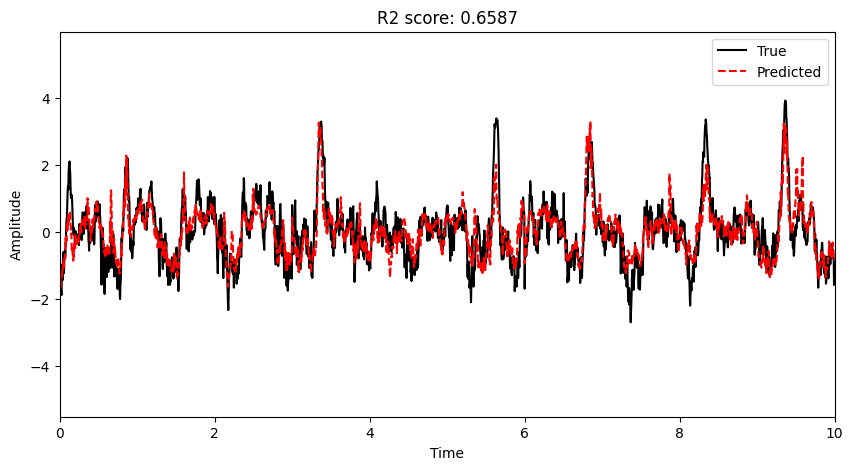

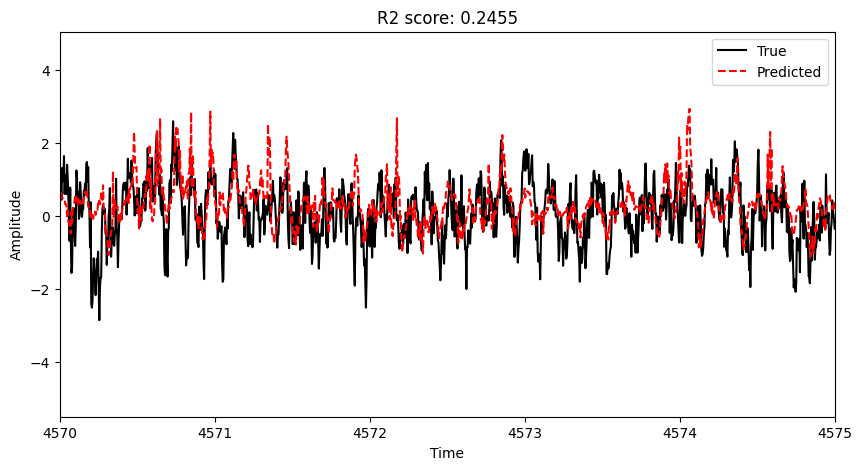

In [22]:
y_hat_test = transformer_model.evaluate(test_spikes)

fig, ax = plt.subplots(1, 1, figsize=(10, 5))
ax.plot(time, test_lfp.cpu().numpy(), 'k', label='True')
ax.plot(time, y_hat_test, '--r', label='Predicted')
ax.set_xlim([0, 10])
ax.set_xlabel('Time')
ax.set_ylabel('Amplitude')
ax.set_title(f'R2 score: {r2_score(test_lfp.cpu().numpy(), y_hat_test):.4f}')
ax.legend()
plt.show()

y_hat_spont = transformer_model.evaluate(torch.tensor(spikes_obj_spont.spkMat).float())

fig, ax = plt.subplots(1, 1, figsize=(10, 5))
ax.plot(spikes_obj_spont.timestamps, lfp_obj_spont.lfpMat[:,chani,bandi], 'k', label='True')
ax.plot(spikes_obj_spont.timestamps, y_hat_spont, '--r', label='Predicted')
ax.set_xlim([spikes_obj_spont.timestamps[0], spikes_obj_spont.timestamps[0]+5])
ax.set_xlabel('Time')
ax.set_ylabel('Amplitude')
ax.set_title(f'R2 score: {r2_score(lfp_obj_spont.lfpMat[:,chani,bandi], y_hat_spont):.4f}')
ax.legend()
plt.show()

## run the LSTM model on all channels and bands

In [23]:
lossesTrain, lossesTest = (np.zeros((len(lfp_obj.channels), num_epochs, len(bands)+1)) for _ in range(2))
R2_train, R2_test       = (np.zeros((len(lfp_obj.channels), len(bands)+1)) for _ in range(2))

# initialize dictionary to store trained models 
all_models = {}

for bandi in range(len(bands)+1):
    sys.stdout.write('\r' + 'Working on band ' + str(bandi + 1) + ' out of ' + str(len(bands)+1) + '\n')
    
    X_train, X_test, y_train, y_test  = chunk_and_reshape(spikes_obj.spkMat, lfp_obj.lfpMat[:,:,bandi] , seqlength, test_size=0.2, random_state=42)

    for chani in range(len(lfp_obj.channels)):
        sys.stdout.write('\t' + 'Training model for channel ' + str(chani+1) + ' out of ' + str(lfp_obj.lfpMat.shape[1]) + '\n')
        
        train_dataloader, test_dataloader = get_data_loaders(X_train, X_test, y_train[:,:,chani], y_test[:,:,chani], batch_size , device)
        
        model = models.process_model(models.LSTMnet(input_size, hidden_size, num_layers,seqlength), criterion, device)
        
        train_loss, test_loss = model.train(train_dataloader,
                                        test_dataloader , num_epochs)
        
        yHat = model.evaluate(test_dataloader.dataset.tensors[0])
        R2_test[chani, bandi] = r2_score(test_dataloader.dataset.tensors[1].cpu().numpy().reshape(-1,1), yHat)
        yHat = model.evaluate(train_dataloader.dataset.tensors[0])
        R2_train[chani, bandi] = r2_score(train_dataloader.dataset.tensors[1].cpu().numpy().reshape(-1,1), yHat)
        
        lossesTrain[chani,:, bandi] = train_loss
        lossesTest[chani,:, bandi] = test_loss
        
        all_models[chani, bandi] = model


Working on band 1 out of 9
	Training model for channel 1 out of 20
	Training model for channel 2 out of 20
	Training model for channel 3 out of 20
	Training model for channel 4 out of 20
	Training model for channel 5 out of 20
	Training model for channel 6 out of 20
	Training model for channel 7 out of 20
	Training model for channel 8 out of 20
	Training model for channel 9 out of 20
	Training model for channel 10 out of 20
	Training model for channel 11 out of 20
	Training model for channel 12 out of 20
	Training model for channel 13 out of 20
	Training model for channel 14 out of 20
	Training model for channel 15 out of 20
	Training model for channel 16 out of 20
	Training model for channel 17 out of 20
	Training model for channel 18 out of 20
	Training model for channel 19 out of 20
	Training model for channel 20 out of 20
Working on band 2 out of 9
	Training model for channel 1 out of 20
	Training model for channel 2 out of 20
	Training model for channel 3 out of 20
	Training model

In [29]:
# get model predictions for the entire active session
yHat_active = np.zeros((lfp_obj.lfpMat.shape[0], lfp_obj.lfpMat.shape[1], len(bands)+1))
for chani in range(len(lfp_obj.channels)):
    for bandi in range(len(bands)+1):
        yHat_active[:,chani,bandi] = all_models[chani, bandi].evaluate(torch.tensor(spikes_obj.spkMat).float().to(device))

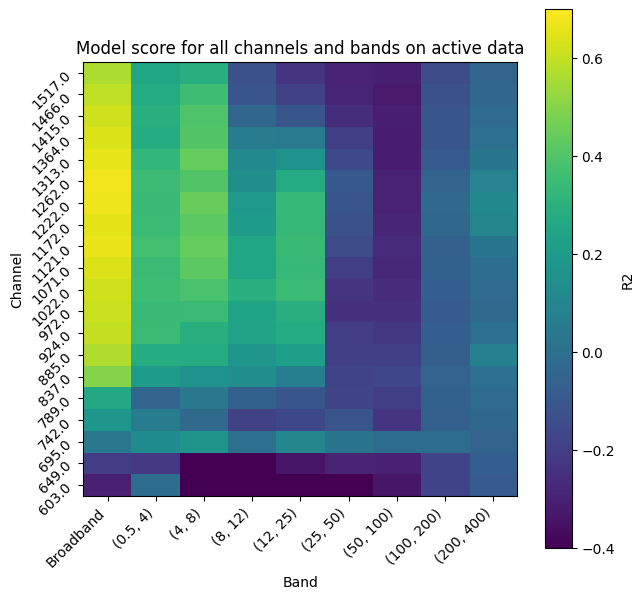

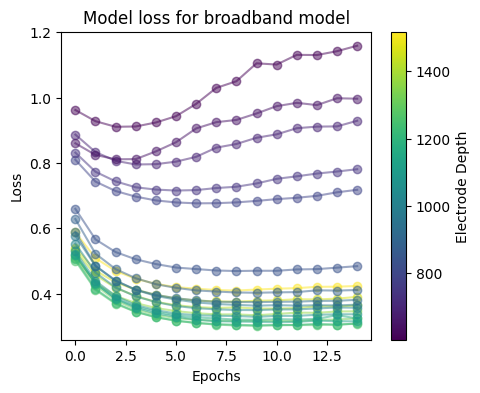

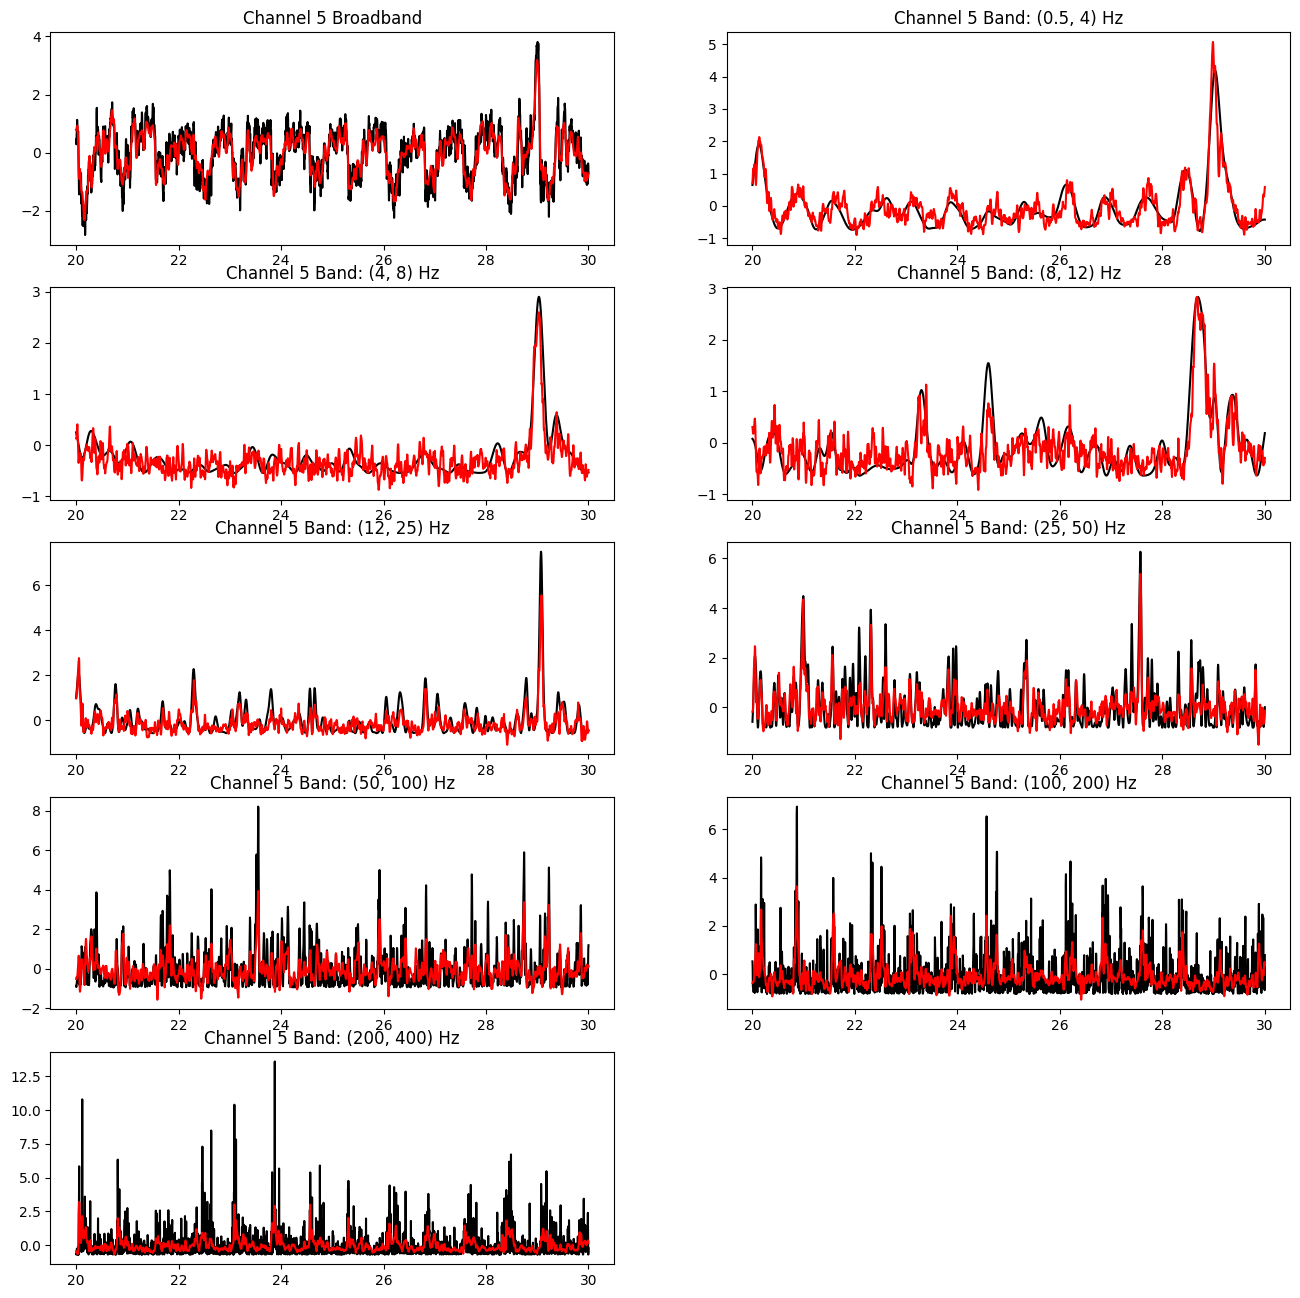

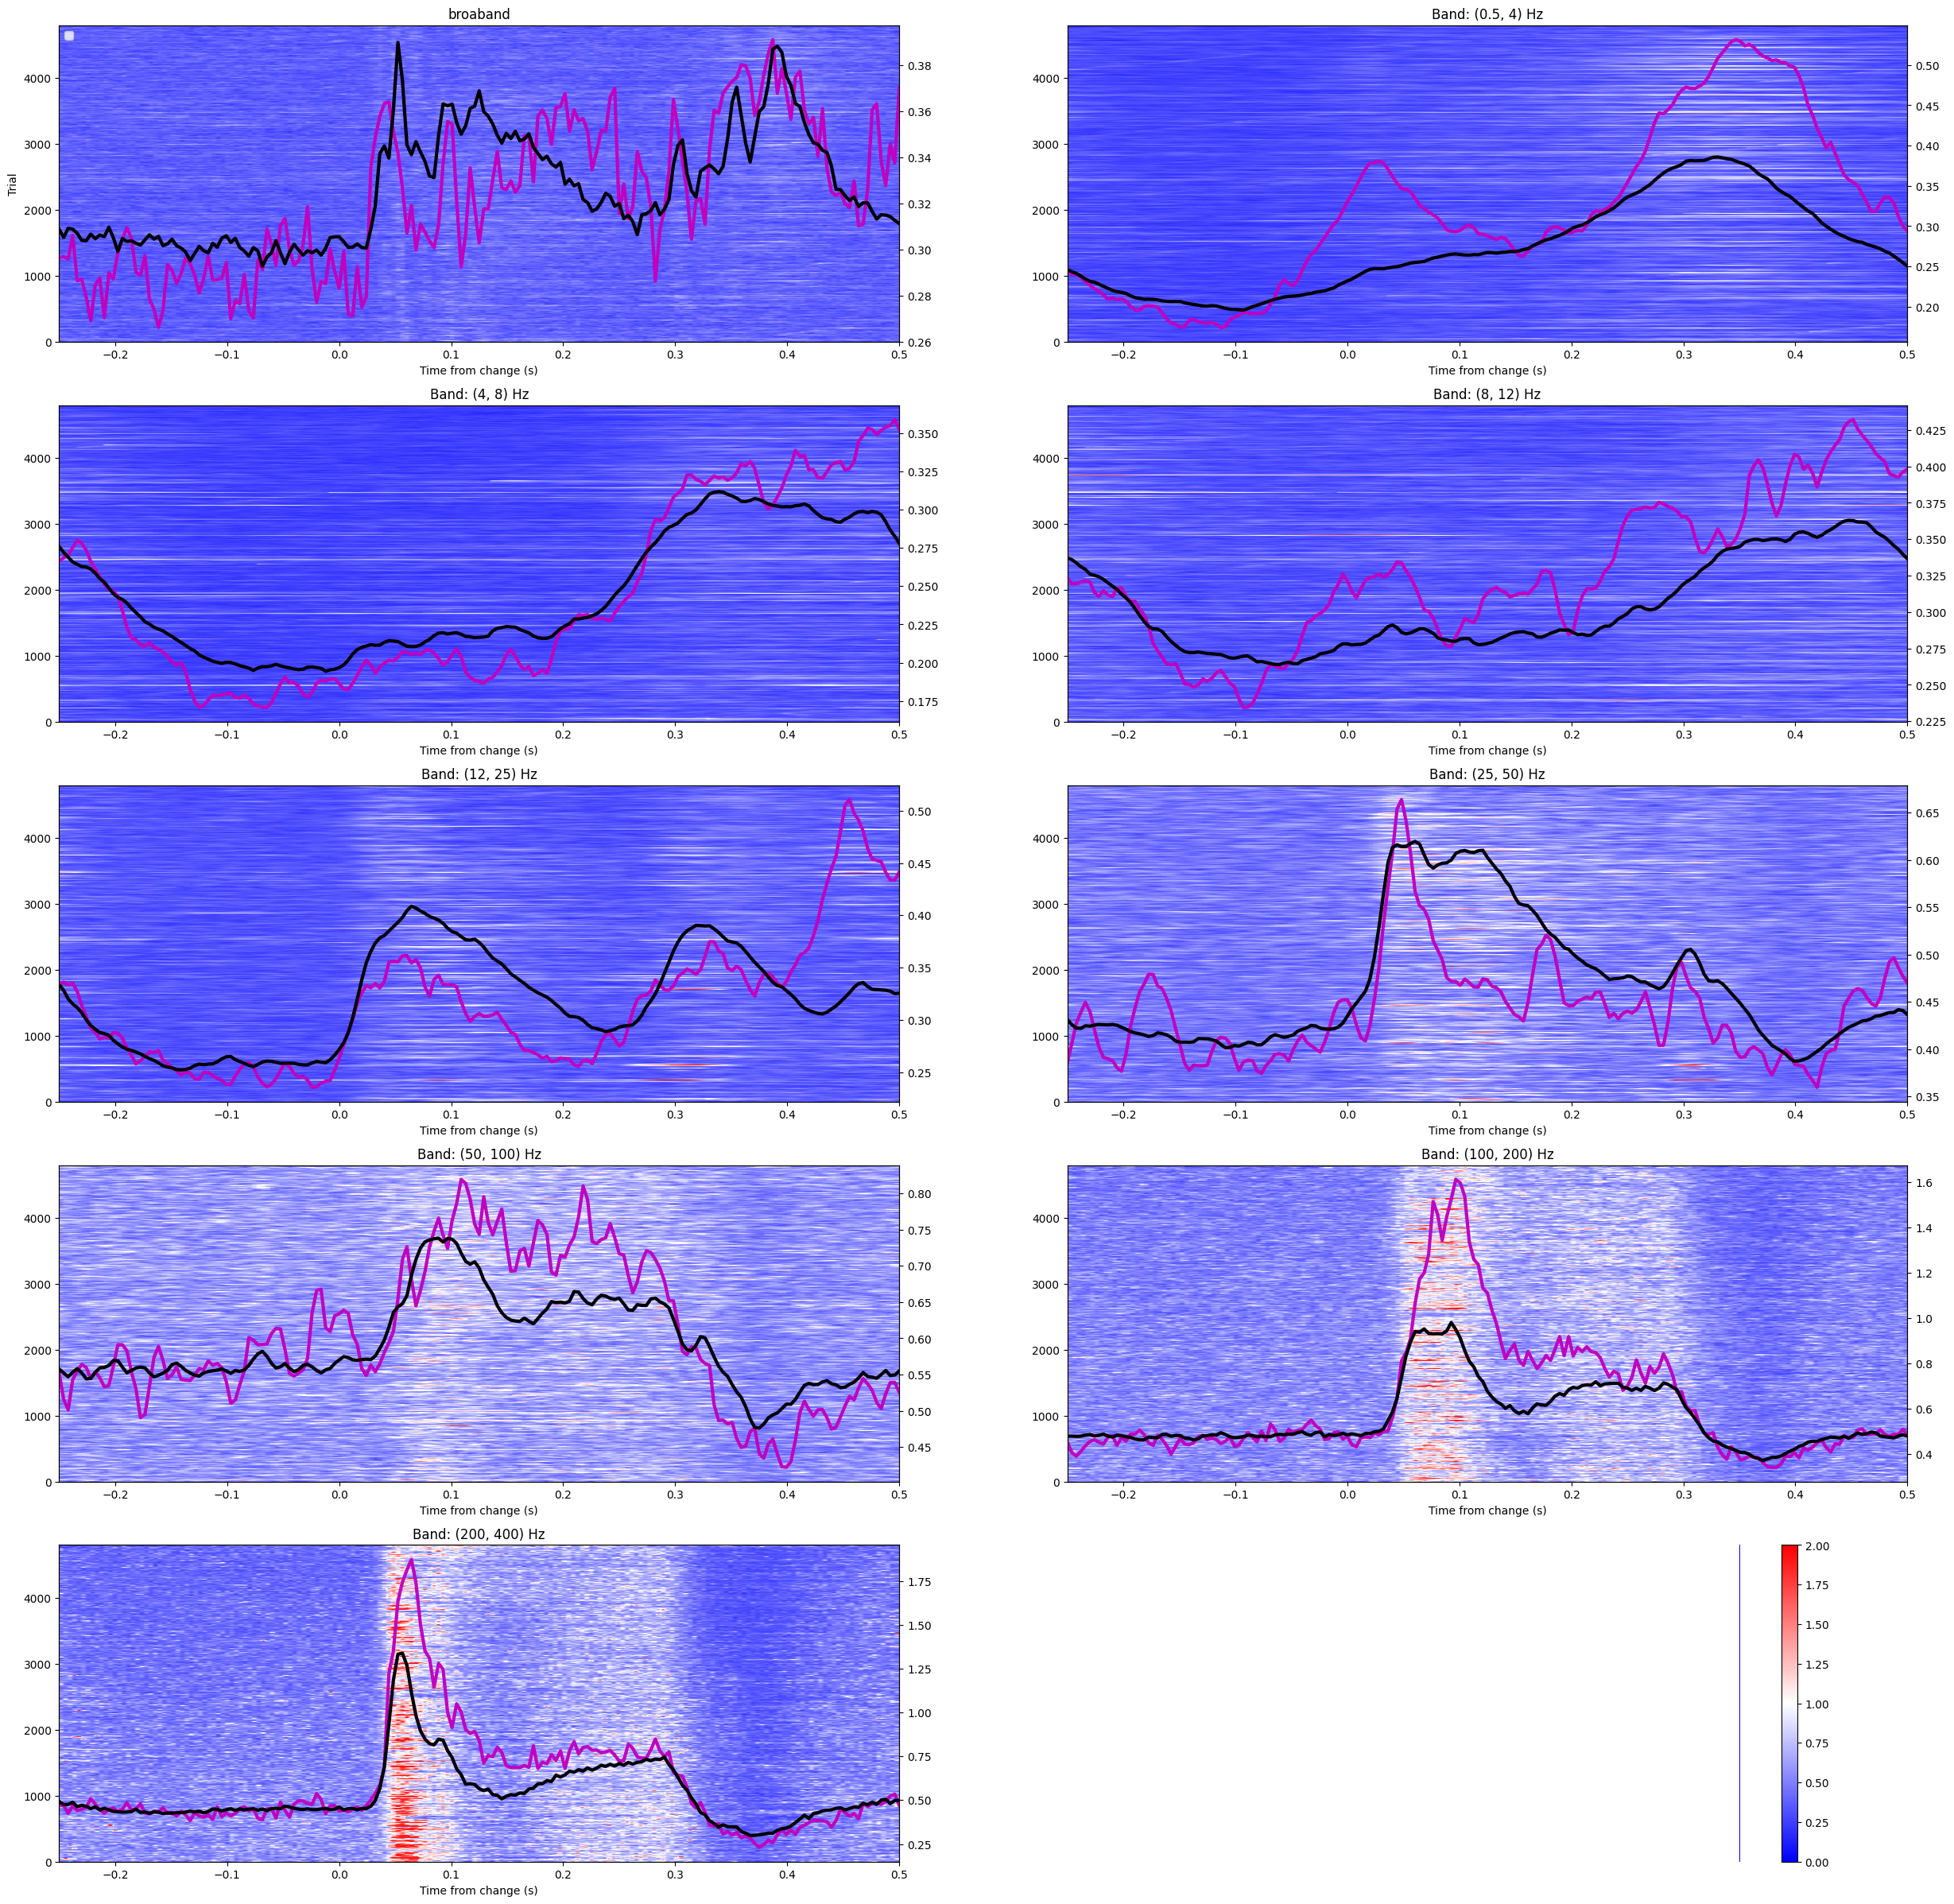

In [52]:
import importlib
import plots
importlib.reload(plots)
from plots import * 

plot_r2(R2_test, lfp_obj.channels, bands)
plot_all_channel_loss(lfp_obj.channels, bands, 0, lossesTest)
plot_lfp_prediction(lfp_obj.lfpMat, yHat_active, 5, bands, start_time = 20, end_time = 30)
plot_abs_error_change(lfp_obj.lfpMat, yHat_active, session_obj, spikes_obj.timestamps, 5, bands)

In [62]:
# save the models 
output_dir = Path(output_dir)
output_dir_models = output_dir / 'models' / str(session_id)
os.makedirs(output_dir_models, exist_ok=True)

for idx in range(len(all_models.keys())):
    chan = list(all_models.keys())[idx][0]
    band = list(all_models.keys())[idx][1]
    filename = output_dir_models / f'lstm_model_chan{chan}_band{band}.pt'
    torch.save(all_models[chan, band].model.state_dict(), filename)

In [70]:
# calculate attribution scores
from process_attribution import * 
divide_task_for_attr(all_models, session_id, output_dir, spikes_obj, bin_size, bands, dur = 720)

RuntimeError: shape '[3115000, -1]' is invalid for input of size 250000

In [76]:
mdl = all_models[0, 0].model.train()
integrated_gradients = IntegratedGradients(mdl)
attributions = []
for i in tqdm.tqdm(range(0,1000,100)):
    attributions.append(integrated_gradients.attribute(torch.tensor(spikes_obj.spkMat[i:i+100,:]).float(),  target=0,  n_steps=50))
attributions = torch.cat(attributions)

  0%|          | 0/10 [00:00<?, ?it/s]


RuntimeError: shape '[3115000, -1]' is invalid for input of size 250000

In [83]:
X_attr = torch.tensor(spikes_obj.spkMat[:int(720/bin_size)]).float()
num_trials = X_attr.shape[0] // seqlength
X_attr_reshaped = X_attr.reshape(num_trials, seqlength, -1)
for i in range(0, X_attr_reshaped.shape[0]):
    # we are now taking each trial (shape = (seq_length, input_size))
    trial = X_attr_reshaped[i]
    attributions.append(integrated_gradients.attribute(trial,n_steps=50).unsqueeze(0))
attributions = torch.cat(attributions).to(torch.float32)
attributions = attributions.cpu().detach()


RuntimeError: shape '[23362500, -1]' is invalid for input of size 1875000

In [82]:
trial.shape

torch.Size([750, 623])